In [2]:
import re
import random
import math
import pandas as pd

In [ ]:
tc_dict = {

    'tôi': ['t'],

    'không': ['ko', 'k', 'kh', 'hông', 'hok', 'kh', 'kg', 'hk', 'hôk', 'khummm', 'khôg', 'hongg'],

    'được': ['đc', 'dc', 'đk'],

    'rồi': ['r', 'rùi'],

    'mày': ['m'],

    'người': ['ng'],

    'vậy': ['z', 'v', 'zị', 'zậy', 'dzị', 'zay', 'dzậy', 'zạy', 'dzạy'],

    'với': ['vs', 'zới', 'dzới'],

    'chuyển khoản': ['ck'],

    'chồng': ['ck', 'ckồnq'],

    'người ta': ['ngta', 'nta', 'ngt'],

    'bạn': ['b', 'bn'],

    'luôn': ['lun', 'luonn', 'lunnn'],

    'gì': ['j', 'zì', 'zề', 'dzề', 'g'],

    'trời': ['tr', 'zời'],

    'giờ': ['h', 'g'],

    'cũng': ['cx', 'cg', 'cũg', 'cug'],

    'mọi người': ['mn', 'mng'],

    'nhưng mà': ['nma', 'nhma', 'nmà', 'nm', 'nhm'],

    'trước': ['trc'],

    'vợ': ['vk', 'zk'],

    'làm': ['lm'],

    'mật khẩu': ['mk'],

    'mình': ['mk', 'mik', 'mìnk', 'mih', 'mìh', 'mìk', 'm', 'mh'],

    'biết': ['bt', 'bik', 'bjk', 'bk'],

    'thôi': ['thui', 'th'],

    'vô': ['zô', 'dzô', 'zo'],

    'sao': ['s', 'shao', 'shaooo'],

    'nói chuyện': ['nc', 'nch'],

    'đi': ['ik'],

    'sinh năm': ['sn'],

    'nó': ['n'],

    'bao giờ': ['bh', 'baoh', 'bgio', 'bg'],

    'bây giờ': ['bh', 'bg', 'bjo', 'bâyh', 'bayh', 'bâyg'],

    'vui': ['zui', 'dzui'],

    'gia đình': ['gđ', 'gd', 'gđinh', 'gđình'],

    'trai': ['zai', 'zaiiii', 'dzai'],

    'công ty': ['cty', 'ct'],

    'điện thoại': ['đt', 'đth', 'dt'],

    'mới': ['ms'],

    'như thế nào': ['ntn'],

    'bình thường': ['bth', 'bthg', 'bt'],

    'nữa': ['nx'],

    'chúng ta': ['cta', 'chta'],

    'học sinh': ['hs', 'hsinh'],

    'à': ['ah', 'ak', 'àh', 'àk'],

    'anh': ['ah', 'ank'],

    'nhắn tin': ['nt', 'ntin'],

    'nói': ['ns'],

    'trong': ['trg'],

    'chuẩn bị': ['cbi', 'cb'],

    'chưa': ['ch', 'chx'],

    'không biết': ['kbt', 'kbiet', 'kb'],

    'kết bạn': ['kb'],

    'chị em': ['ce'],

    'sinh viên': ['sv', 'svien'],

    'đúng không': ['đk', 'dk'],

    'bố mẹ': ['bme', 'bm'],

    'thằng': ['tk', 'thg', 'thk'],

    'học': ['hc', 'hok'],

    'quá': ['qá', 'wa', 'qa', 'q', 'qs', 'qó', 'quák', 'wa', 'qus'],

    'phải': ['ph', 'p'],

    'nhưng': ['nhg', 'nhưg'],

    'thường': ['thg'],

    'có': ['cs'],

    'khóc': ['khók', 'khok'],

    'đang': ['đg', 'đag', 'dg'],

    'mấy giờ': ['mh'],

    'thành phố': ['tp'],

    'nhiệm vụ': ['nv'],

    'xong': ['xog', 'xg', 'xoq'],

    'công việc': ['cv', 'cviec'],

    'như này': ['nnay'],

    'chị': ['cj', 'chj', 'c'],

    'các bạn': ['cb', 'cban'],

    'chúng nó': ['cno', 'chn'],

    'nhiều': ['nh'],

    'hôm qua': ['hqua'],

    'chơi': ['chs'],

    'xin lỗi': ['xl', 'xinloi', 'xloi'],

    'hôm nay': ['hnay'],

    'nha': ['nka'],

    'hôm nào': ['hnao'],

    'kiểm tra': ['ktra', 'kt', 'ktr'],

    'bóng': ['pónk', 'bónk'],

    'cứu': ['cíu'],

    'quan tâm': ['qtam', 'qt'],

    'như thế': ['nthe'],

    'già': ['zà'],

    'sức khỏe': ['sk', 'skhoe'],

    'không phải': ['kp', 'kphai', 'kph'],

    'quan trọng': ['qtrong', 'qtr', 'qt'],

    'nè': ['nek', 'nèk', 'neh'],

    'thời gian': ['tgian', 'tg', 'thgian'],

    'dễ thương': ['dth', 'dthw'],

    'ác': ['ák'],

    'độc': ['độk'],

    'thế này': ['tnay', 'tn'],

    'ông': ['ôg'],

    'không sao': ['ks', 'ksao'],

    'chia tay': ['ctay', 'ct', 'chtay'],

    'người khác': ['ngkhac', 'ngkh', 'ngk'],

    'bác sĩ': ['bsi'],

    'cái gì': ['cgi'],

    'ba mẹ': ['bame'],

    'giáo viên': ['gv'],

    'chủ nhật': ['cn'],

    'thật': ['tht'],

    'buồn cười': ['bcuoi'],

    'trả lời': ['tl', 'trl'],

    'thích': ['thik', 'thík', 'thk'],

    'dữ': ['zữ', 'dzữ'],

    'như vậy': ['nvay'],

    'tại sao': ['ts', 'tsao'],

    'con gái': ['cgai', 'cgái'],

    'cảm': ['kảm'],

    'làm gì': ['lgi', 'lmj'],

    'mà': ['mak', 'màk'],

    'đó': ['đók', 'ds'],

    'kinh tế': ['kte', 'kt'],

    'chúng mày': ['cm', 'cmay'],

    'viết': ['vt'],

    'sinh nhật': ['snhat', 'sn'],

    'cuộc sống': ['csong', 'cs'],

    'việc': ['ziệc'],

    'đăng ký': ['đki', 'đk', 'dki', 'đky'],

    'quân sự': ['qsu'],

    'ghê': ['gke'],

    'hết': ['ht'],

    'ví dụ': ['vd'],

    'ngon': ['ngol'],

    'thế nào': ['tnao'],

    'dạo này': ['dnay'],

    'vợ chồng': ['vkck'],

    'đáng': ['đág'],

    'suy nghĩ': ['snghi'],

    'con tria': ['ctrai'],

    'đẹp trai': ['đtrai', 'dzai', 'dz', 'đzai', 'đz'],

    'hôm sau': ['hsau'],

    'thương': ['thw'],

    'vấn đề': ['vde', 'vđ', 'vđề', 'vđe'],

    'bạn bè': ['bb', 'bbe'],

    'ạ': ['ạk'],

    'cute': ['cuti'],

    'trà sữa': ['tsua'],

    'bao nhiêu': ['bnhieu', 'bnh', 'bnhiu', 'bn'],

    'gì vậy': ['jz', 'jv'],

    'nói chung': ['nchung', 'nc', 'nch'],

    'quay lại': ['qlai'],

    'là sao': ['lsao'],

    'ừ': ['uk', 'uhm', 'uh'],

    'công': ['côg'],

    'rảnh': ['gảnk'],

    'kinh nghiệm': ['kn'],

    'nhân viên': ['nvien', 'nv'],

    'ngược': ['ngc'],

    'vụ': ['zụ'],

    'em bé': ['embe', 'ebe'],

    'xinh': ['xinhh', 'xjnk', 'xink'],

    'dạ': ['zạ'],

    'khùng': ['khùg'],

    'hôm trước': ['htrc'],

    'chương trình': ['ctrinh'],

    'hic': ['hjc'],

    'á': ['as'],

    'ngốc': ['ngốk'],

    'không bao giờ': ['kbg', 'kbh'],

    'chúng tôi': ['ctoi'],

    'điều kiện': ['đkien'],

    'vừa': ['dzừa'],

    'lạnh': ['lạnk'],

    'diễn viên': ['dvien'],

    'việt': ['ziệt'],

    'chúng': ['chúg'],

    'tham gia': ['tgia'],

    'thông báo': ['tbao', 'tb'],

    'tin nhắn': ['tnhan'],

    'trông': ['trôg'],

    'sử dụng': ['sd'],

    'tính': ['tíh'],

    'đỉnh': ['đỉnk'],

    'vịt': ['dzịt'],

    'giang hồ': ['yangho'],

    'quay': ['qay'],

    'nách': ['náck'],

    'dí': ['zdí'],

    'đúng rồi': ['đr', 'dr', 'đrui'],

    'bản thân': ['bthan'],

    'bắt đầu': ['bdau'],

    'chứng minh': ['cm'],

    'con': ['c', 'cn'],

    'cái này': ['cnay'],

    'cà phê': ['cf'],

    'công khai': ['ckhai'],

    'cảm giác': ['cgiac'],

    'cộng đồng mạng': ['cđm'],

    'dịch vụ': ['dv'],

    'giao dịch': ['gd'],

    'giải thích': ['gth'],

    'giới thiệu': ['gth'],

    'hay sao ý': ['hsy'],

    'hình như': ['hnhu'],

    'hướng dẫn': ['hd'],

    'hạnh phúc': ['hp'],

    'học kỳ': ['hk'],

    'học phí': ['hp'],

    'hồ sơ': ['hs'],

    'hợp đồng': ['hd'],

    'khách sạn': ['ks'],

    'không có': ['kco'],

    'không hiểu sao': ['khs'],

    'không liên quan': ['klq'],

    'kiến thức': ['kthuc'],

    'kết quả': ['kqua'],

    'kết thúc': ['kthuc'],

    'kỹ năng': ['kn'],

    'liên hệ': ['lh'],

    'liên quan': ['lquan', 'lq'],

    'làm sao': ['lsao', 'lms'],

    'màn hình': ['mh'],

    'mạng xã hội': ['mxh'],

    'mối quan hệ': ['mqh'],

    'ngân hàng': ['nh'],

    'nhân vật': ['nv'],

    'như nào': ['nnao'],

    'nhận xét': ['nx'],

    'những': ['nhx'],

    'nói chung là': ['ncl'],

    'nước': ['nc'],

    'phòng': ['p'],

    'quảng cáo': ['qcao'],

    'quốc tế': ['qt'],

    'rẻ': ['zẻ'],

    'số điện thoại': ['sdt', 'sđt'],

    'tao': ['t'],

    'thanh toán': ['tt'],

    'thông tin': ['ttin'],

    'thế': ['z'],

    'thực sự': ['thsu'],

    'tiktok': ['tik'],

    'trung bình': ['tb'],

    'trường': ['trg'],

    'trực tiếp': ['tt'],

    'tài chính': ['tc'],

    'tài khoản': ['tk'],

    'tình cảm': ['tc', 'tcam'],

    'tốt nghiệp': ['tn'],

    'tự nhiên': ['tnh', 'tnhien'],

    'vui vẻ': ['zẻ', 'vv'],

    'vậy ta': ['vt'],

    'ý kiến riêng': ['ykr'],

    'đường': ['đg'],

    'được không': ['dko'],

    'đại học': ['đh']

}



In [9]:
MAX_NGRAM = max([len(k.split()) for k in tc_dict.keys()]) if tc_dict else 1

In [14]:
def process_sentence(sentence, max_tc_prob):
    if not sentence or not isinstance(sentence, str):
        return ""

    words = sentence.split()
    if not words: return ""
    
    # 1. Bóc tách
    raw = []
    for w in words:
        m = re.match(r"^([^\W_]+)(.*)$", w, re.UNICODE)
        if m:
            raw.append({
                'core': m.group(1).lower(), 
                'punct': m.group(2), 
                'title': m.group(1).istitle(), 
                'upper': m.group(1).isupper(), 
                'valid': True, 
                'original': w
            })
        else:
            raw.append({'valid': False, 'original': w})

    # 2. Tokenization
    tokens, i = [], 0
    while i < len(raw):
        if not raw[i]['valid']:
            tokens.append(raw[i]); i += 1
        else:
            found = False
            for n in range(MAX_NGRAM, 0, -1):
                if i + n <= len(raw) and all(raw[i+k]['valid'] for k in range(n)):
                    comb = " ".join([raw[i+k]['core'] for k in range(n)])
                    if comb in tc_dict:
                        tokens.append({
                            'core': comb, 
                            'punct': raw[i+n-1]['punct'], 
                            'title': raw[i]['title'], 
                            'upper': raw[i]['upper'], 
                            'valid': True, 
                            'original': " ".join([raw[i+k]['original'] for k in range(n)])
                        })
                        i += n; found = True; break
            if not found:
                tokens.append(raw[i]); i += 1

    # --- LOGIC MỚI TẠI ĐÂY ---
    # 3. PHÂN BỔ QUOTA DỰA TRÊN TỈ LỆ TỐI ĐA (max_tc_prob)
    
    # Danh sách index các từ ĐÃ LÀ teencode (ví dụ "ko", "j", "mìh")
    # Chúng ta check xem 'core' có nằm trong GIÁ TRỊ (values) của tc_dict không
    existing_tc_indices = []
    all_tc_variants = set([v for sublist in tc_dict.values() for v in sublist])
    
    # Danh sách index các từ CÓ THỂ chuyển thành teencode (đang là tiếng Việt chuẩn)
    potential_tc_indices = []
    
    for idx, t in enumerate(tokens):
        if not t['valid']: continue
        if t['core'] in all_tc_variants:
            existing_tc_indices.append(idx)
        elif t['core'] in tc_dict:
            potential_tc_indices.append(idx)

    # Tổng số teencode tối đa cho phép trong câu
    max_allowed_tc = math.floor(len(tokens) * max_tc_prob)
    
    # Số lượng teencode cần thêm mới
    num_to_add = max(0, max_allowed_tc - len(existing_tc_indices))
    
    # Đảm bảo không chọn vượt quá số lượng từ tiếng Việt chuẩn đang có
    num_to_add = min(num_to_add, len(potential_tc_indices))
    
    # Chọn ngẫu nhiên các index để chuyển đổi
    tc_chosen = set(random.sample(potential_tc_indices, num_to_add)) if potential_tc_indices and num_to_add > 0 else set()
    # -------------------------

    # 4. Render
    output = []
    for idx, d in enumerate(tokens):
        # Nếu không được chọn để đổi, giữ nguyên (bao gồm cả những từ đã là teencode sẵn)
        if idx not in tc_chosen:
            output.append(d['original'])
            continue

        core = d['core']
        vars = tc_dict[core]
        new = random.choices(vars, weights=[1.0/(2**j) for j in range(len(vars))], k=1)[0]

        if d['upper']: new = new.upper()
        elif d['title']: new = new.capitalize()
            
        output.append(new + d['punct'])

    return " ".join(output), {'tc_added': len(tc_chosen), 'tc_existing': len(existing_tc_indices)}

In [18]:
process_sentence('k bt ngu kh bíc dm như cl ko bt nma nhma nhưng mà không không không không không', 0.9)

('k bt ngu kh bíc dm như cl ko bt nma nhma nma ko ko k ko ko',
 {'tc_added': 6, 'tc_existing': 7})

In [19]:
df = pd.read_csv('final_cleaned_threads.csv', encoding= 'utf-8')
df

,text,target
0,anh cho bạn em ứng tuyển ạ,anh cho bạn em ứng tuyển ạ
1,Cô để cho các cháu kiếm cơm 😂,Cô để cho các cháu kiếm cơm 😂
2,nếu ra trg muộn vấn là sv,nếu ra trường muộn vẫn là sinh viên
3,e 2k7 svien ngành sư phạm ngữ văn a ơiii,em 2k7 sinh viên ngành sư phạm ngữ văn anh ơi
4,Bạn em .03 làm kế toán công ty xuất nhập khẩu ...,Bạn em .03 làm kế toán công ty xuất nhập khẩu ...
...,...,...
18421,"Nếu cô ấy: ngoan nhưng khôn, chân thành, biết ...","Nếu cô ấy: ngoan nhưng khôn, chân thành, biết ..."
18422,Đàn ông họ có trải nghiệm rồi không còn hứng t...,Đàn ông họ có trải nghiệm rồi không còn hứng t...
18423,Mây tầng nào sẽ gặp tầng đó.,Mây tầng nào sẽ gặp tầng đó.
18424,Nhưng hông phải ai cũng ăn may nên thôi mình l...,Nhưng không phải ai cũng ăn may nên thôi mình ...


In [37]:
max_tc_prob_list = [0.3, 0.5, 0.7,  0.9]

for prob in max_tc_prob_list:
    # 1. Gọi hàm process_sentence với tham số prob
    # result sẽ là một Series chứa các tuple (processed_text, info_dict)
    results = df['text'].apply(lambda x: process_sentence(x, prob))
    
    # 2. Tạo một bản sao DataFrame để không ghi đè lên df gốc ở vòng lặp sau
    df_temp = df.copy()
    
    # 3. Lấy phần tử đầu tiên của tuple (văn bản đã xử lý) gán vào cột text
    df_temp['text'] = results.apply(lambda x: x[0])
    
    # 4. Xuất CSV theo format yêu cầu: chỉ text và target, không header
    # Giả sử cột nhãn của bạn tên là 'target'
    df_temp[['text', 'target']].to_csv(
        f'teencode_{prob}.csv', 
        index=False, 
        encoding='utf-8'
    )

In [38]:
tc07 = pd.read_csv('teencode_0.7.csv', encoding = 'utf-8')
tc03 = pd.read_csv('teencode_0.3.csv', encoding = 'utf-8')
tc05 = pd.read_csv('teencode_0.5.csv', encoding = 'utf-8')
tc09 = pd.read_csv('teencode_0.9.csv', encoding = 'utf-8')




In [30]:
def count_tc(df):
    all_tc_variants = set(variant for variants in tc_dict.values() for variant in variants)    
    prob_lst = []
    count_lst = []
    
    for i, row in df.iterrows():
        sentence = row['text']
        if not isinstance(sentence, str) or not sentence.strip():
            count_lst.append(0)
            prob_lst.append(0)
            continue
            
        words = sentence.split()
        tc_count = 0
        
        for w in words:
            # Tách phần chữ và phần dấu câu/emoji
            m = re.match(r"^([^\W_]+)(.*)$", w, re.UNICODE)
            if m:
                # Chuyển về lowercase để so khớp chính xác với tc_dict
                if m.group(1).lower() in all_tc_variants:
                    tc_count += 1
        
        # Tính toán tỉ lệ dựa trên số từ của chính câu đó
        N = len(words)
        count_lst.append(tc_count)
        prob_lst.append(tc_count / N if N > 0 else 0)
        
    return count_lst, prob_lst

In [46]:
import matplotlib.pyplot as plt

0.28540340893169736


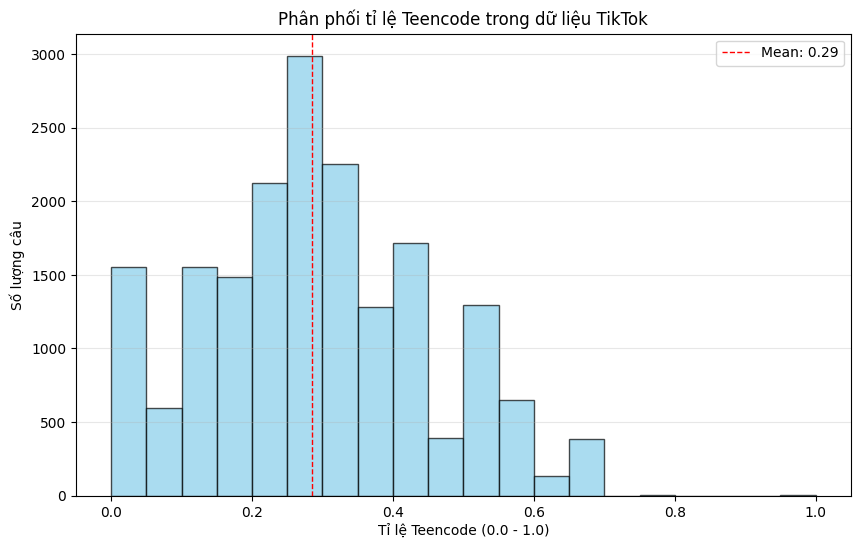

0.2725744634935543


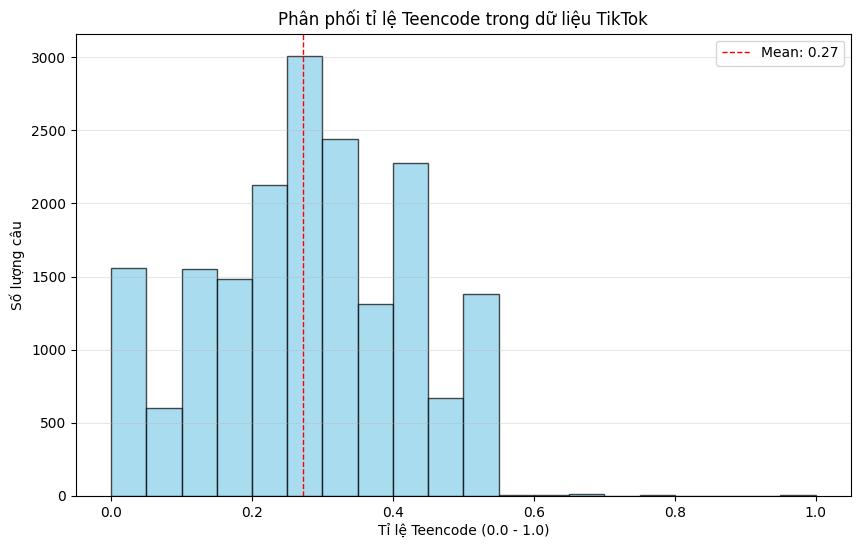

0.2725744634935543


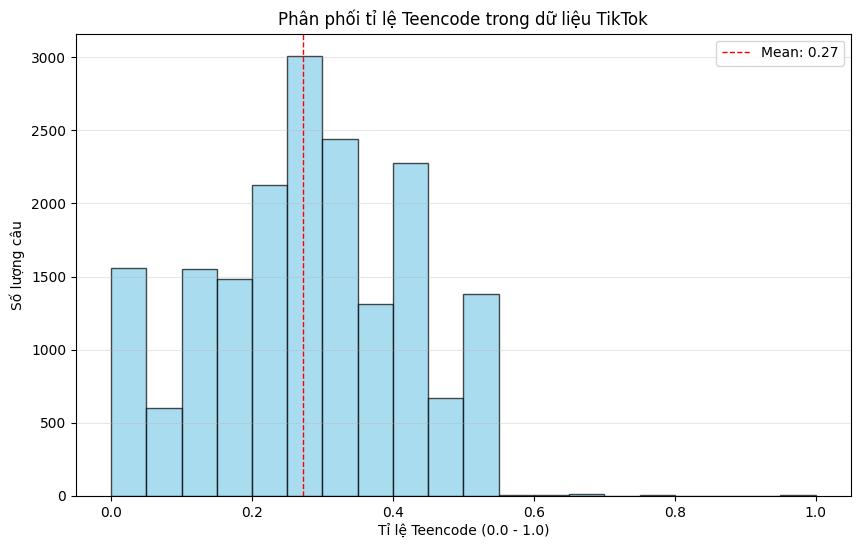

0.2886020761615795


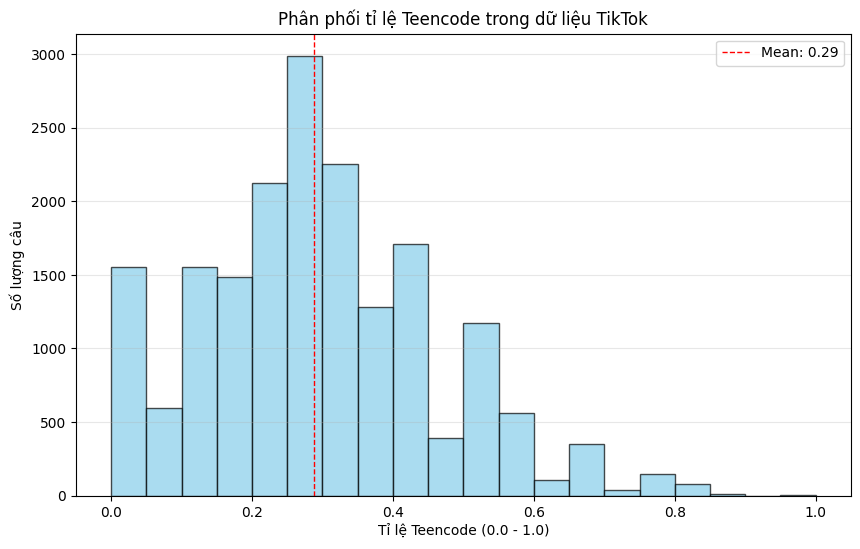

In [ ]:
def plot_teencode_dist(prob_lst):
    plt.figure(figsize=(10, 6))
    
    # Vẽ biểu đồ cột tần suất
    plt.hist(prob_lst, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    
    # Thêm các đường thông số trung bình
    mean_val = sum(prob_lst) / len(prob_lst)
    plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_val:.2f}')
    
    plt.title('Phân phối tỉ lệ Teencode trong dữ liệu TikTok')
    plt.xlabel('Tỉ lệ Teencode (0.0 - 1.0)')
    plt.ylabel('Số lượng câu')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    
    plt.show()

for df in [tc07, tc03, tc05, tc09]:
    prob_lst = count_tc(df)[1]
    mean_prob = sum(prob_lst) / len(prob_lst) if len(prob_lst) > 0 else 0
    print(mean_prob)
    plot_teencode_dist(prob_lst)




In [ ]:
all_tc_variants = set(variant for variants in tc_dict.values() for variant in variants)
for i, row in df.iterrows():
       
